In [7]:
#Import Library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline


In [8]:
from google.colab import files

# Load Excel file
df = pd.read_csv('master_table.csv')

## Basic Cleaning

In [9]:
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])

df['year'] = df['order_purchase_timestamp'].dt.year
df['month'] = df['order_purchase_timestamp'].dt.month

In [10]:
df['customer_state'].unique()

array(['RJ', 'SP', 'MG', 'PR', 'GO', 'BA', 'AL', 'MS', 'CE', 'DF', 'RS',
       'PE', 'SC', 'ES', 'MA', 'PA', 'MT', 'PB', 'AM', 'AP', 'PI', 'TO',
       'RO', 'RN', 'SE', 'AC', 'RR'], dtype=object)

In [11]:
brazil_states = {
    'AC': 'Acre',
    'AL': 'Alagoas',
    'AP': 'Amapa',
    'AM': 'Amazonas',
    'BA': 'Bahia',
    'CE': 'Ceara',
    'DF': 'Distrito Federal',
    'ES': 'Espirito Santo',
    'GO': 'Goias',
    'MA': 'Maranhao',
    'MT': 'Mato Grosso',
    'MS': 'Mato Grosso do Sul',
    'MG': 'Minas Gerais',
    'PA': 'Para',
    'PB': 'Paraiba',
    'PR': 'Parana',
    'PE': 'Pernambuco',
    'PI': 'Piaui',
    'RJ': 'Rio de Janeiro',
    'RN': 'Rio Grande do Norte',
    'RS': 'Rio Grande do Sul',
    'RO': 'Rondonia',
    'RR': 'Roraima',
    'SC': 'Santa Catarina',
    'SP': 'Sao Paulo',
    'SE': 'Sergipe',
    'TO': 'Tocantins'
}

df['customer_state_full'] = df['customer_state'].map(brazil_states)

## Insights

1. Sales Trend Over Time

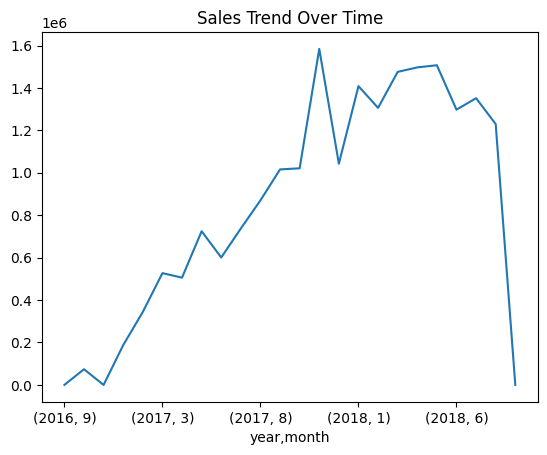

In [38]:
# Sales Trend Over Time
sales_trend = df.groupby(['year','month'])['payment_value'].sum()

sales_trend.plot()
plt.title("Sales Trend Over Time")
plt.show()

2. Top Product Categories

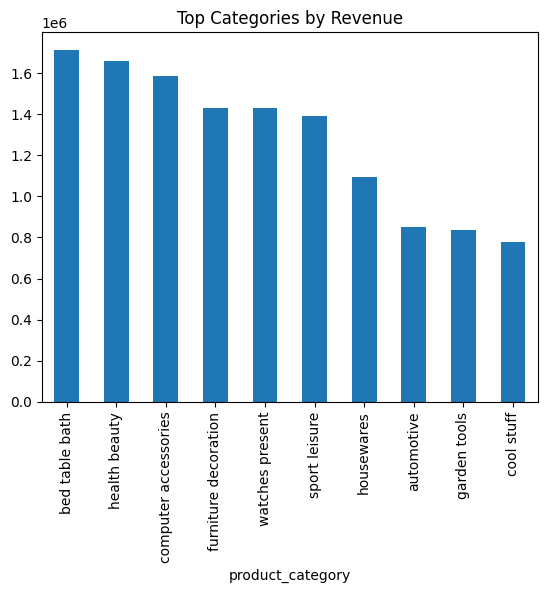

In [41]:
top_categories = df.groupby('product_category')['payment_value'].sum().sort_values(ascending=False).head(10)

top_categories.plot(kind='bar')
plt.title("Top Categories by Revenue")
plt.show()

3. Customer Distribution

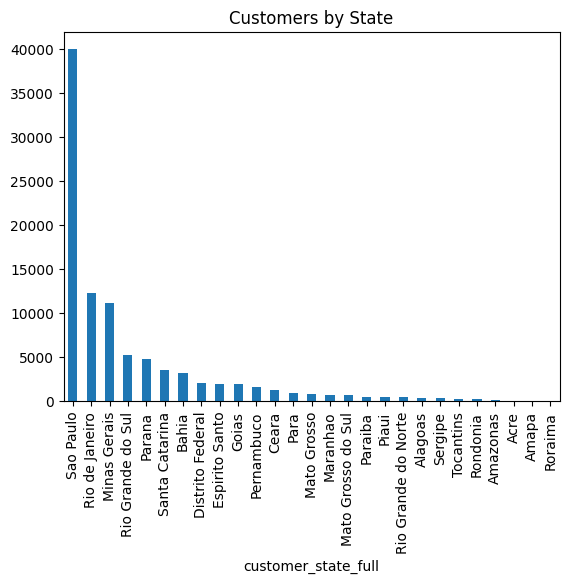

In [43]:
customer_dist = df.groupby('customer_state_full')['customer_unique_id'].nunique().sort_values(ascending=False)

customer_dist.plot(kind='bar')
plt.title("Customers by State")
plt.show()

4. Payment Behavior

In [15]:
installment_rate = (df['payment_installments'] > 1).mean() * 100
print(installment_rate)

50.152205707288864


5. Delivery Performance

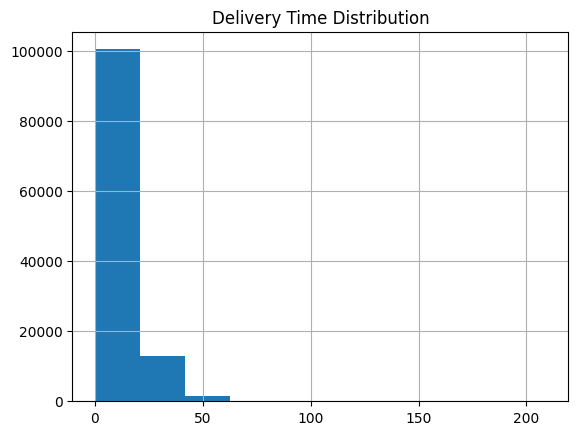

In [51]:
df['delivery_time'] = (
    pd.to_datetime(df['order_delivered_customer_date']) -
    pd.to_datetime(df['order_purchase_timestamp'])
).dt.days

df['delivery_time'].hist()
plt.title("Delivery Time Distribution")
plt.show()

6. Seller Performance

In [52]:
seller_perf = df.groupby('seller_id')['payment_value'].sum().sort_values(ascending=False).head(10)

seller_perf.plot(kind='bar')
plt.title("Top Sellers")
plt.show()

,payment_value
seller_id,
7c67e1448b00f6e969d365cea6b010ab,507166.91
1025f0e2d44d7041d6cf58b6550e0bfa,308222.04
4a3ca9315b744ce9f8e9374361493884,301245.27
1f50f920176fa81dab994f9023523100,290253.42
53243585a1d6dc2643021fd1853d8905,284903.08
da8622b14eb17ae2831f4ac5b9dab84a,272219.32
4869f7a5dfa277a7dca6462dcf3b52b2,264166.12
955fee9216a65b617aa5c0531780ce60,236322.30
fa1c13f2614d7b5c4749cbc52fecda94,206513.23


7. Price vs Demand

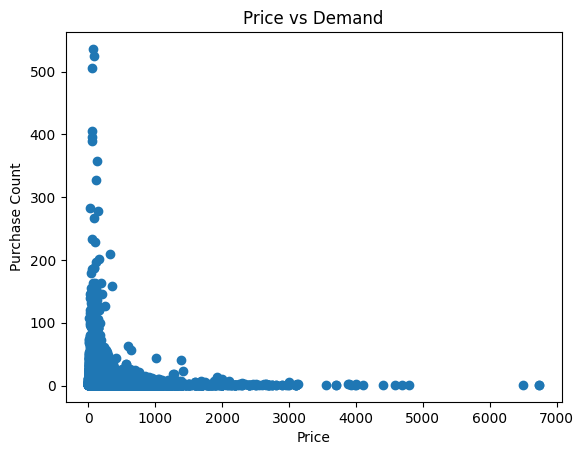

In [54]:
product_analysis = df.groupby('product_id').agg({
    'price': 'mean',
    'product_id': 'count'
}).rename(columns={'product_id':'purchase_count'})

plt.scatter(product_analysis['price'], product_analysis['purchase_count'])
plt.title("Price vs Demand")
plt.xlabel("Price")
plt.ylabel("Purchase Count")
plt.show()

8. Customer Retention

In [19]:
first_purchase = df.groupby('customer_unique_id')['order_purchase_timestamp'].min()

repeat = df.merge(first_purchase, on='customer_unique_id')
repeat = repeat[
    (repeat['order_purchase_timestamp_x'] > repeat['order_purchase_timestamp_y']) &
    (repeat['order_purchase_timestamp_x'] <= repeat['order_purchase_timestamp_y'] + pd.DateOffset(months=6))
]

retention_rate = repeat['customer_unique_id'].nunique() / df['customer_unique_id'].nunique() * 100
print(retention_rate)

2.2720603647034165


9. Top Performing States (by Revenue)

In [61]:
state_performance = df.groupby('customer_state_full')['payment_value'].sum().sort_values(ascending=False)

state_performance.head(10)

,payment_value
customer_state_full,
Sao Paulo,7597209.66
Rio de Janeiro,2769347.44
Minas Gerais,2326151.64
Rio Grande do Sul,1147277.00
Parana,1064603.99
Bahia,797410.36
Santa Catarina,786343.71
Goias,513879.00
Distrito Federal,432623.73


10. Top Performing Cities (by Revenue)

In [21]:
city_performance = df.groupby('customer_city')['payment_value'].sum().sort_values(ascending=False)

city_performance.head(10)

,payment_value
customer_city,
sao paulo,2839903.47
rio de janeiro,1566591.49
belo horizonte,501261.50
brasilia,430499.43
curitiba,329321.54
porto alegre,315729.22
salvador,289139.66
campinas,267039.20
goiania,212702.97


11. Combine Revenue + Orders

In [22]:
city_summary = df.groupby('customer_city').agg({
    'payment_value': 'sum',
    'order_id': 'nunique'
}).rename(columns={
    'payment_value': 'total_revenue',
    'order_id': 'total_orders'
}).sort_values(by='total_revenue', ascending=False)

city_summary.head(10)

,total_revenue,total_orders
customer_city,,
sao paulo,2839903.47,15402
rio de janeiro,1566591.49,6834
belo horizonte,501261.50,2750
brasilia,430499.43,2116
curitiba,329321.54,1510
porto alegre,315729.22,1372
salvador,289139.66,1238
campinas,267039.20,1429
goiania,212702.97,687


12. Revenue per Customer

In [23]:
state_efficiency = df.groupby('customer_state_full').agg({
    'payment_value': 'sum',
    'customer_unique_id': 'nunique'
})

state_efficiency['revenue_per_customer'] = (
    state_efficiency['payment_value'] / state_efficiency['customer_unique_id']
)

state_efficiency.sort_values(by='revenue_per_customer', ascending=False).head(10)

,payment_value,customer_unique_id,revenue_per_customer
customer_state_full,,,
Paraiba,180984.19,516,350.744554
Acre,24984.86,77,324.478701
Amapa,21642.70,67,323.025373
Mato Grosso,256804.62,873,294.163368
Piaui,136779.96,481,284.365821
Rondonia,65886.00,235,280.365957
Alagoas,111284.42,399,278.908321
Para,261788.35,944,277.318167
Roraima,12462.21,45,276.938000


##### 13. Customer Lifetime Value
###### Who are your most valuable customers over time?

In [25]:
clv = df.groupby('customer_unique_id')['payment_value'].sum().sort_values(ascending=False)

clv.head(5)

,payment_value
customer_unique_id,
0a0a92112bd4c708ca5fde585afaa872,109312.64
698e1cf81d01a3d389d96145f7fa6df8,45256.00
c402f431464c72e27330a67f7b94d4fb,44048.00
4007669dec559734d6f53e029e360987,36489.24
ef8d54b3797ea4db1d63f0ced6a906e9,30186.00


 Average Order Value (AOV)

In [27]:
aov = df.groupby('order_id')['payment_value'].sum().mean()
print(aov)

205.82708035189427


Revenue by Payment Type

<Axes: xlabel='payment_type'>

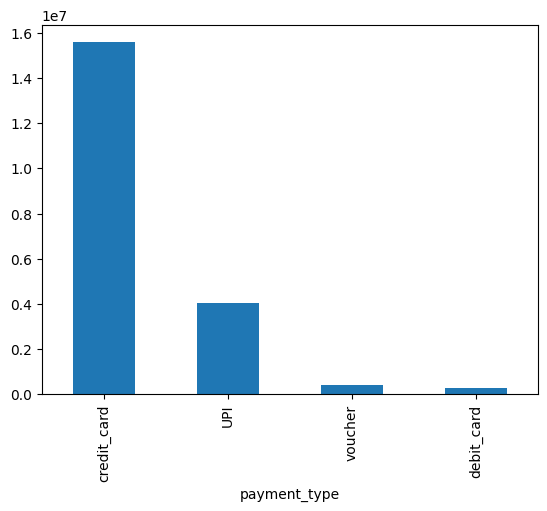

In [63]:
payment_type = df.groupby('payment_type')['payment_value'].sum().sort_values(ascending=False)

payment_type.plot(kind='bar')